# Project 7 — Notebook 22: Temporal Feature Engineering & Breach Profiling

### Hour-of-day, day-of-week, and scheduling context for NCR fault tickets

---

**Origin of this analysis:**  
NB03 Section 7c flagged temporal decomposition as deferred: *"day-of-week SLA patterns, evening breach concentration, and seasonal volume spikes are present in the data and are structurally linked to the Sun–Thu / Tue–Sat team schedule."* This notebook delivers that decomposition.

**Questions answered:**
1. At what hours of the day do SLA breaches concentrate?
2. Which days of the week carry the highest breach rates, and does this align with roster boundaries?
3. Are evening/overnight tickets structurally different from daytime tickets — and is the gap explained by resolution path?
4. Which zones are most exposed to time-of-day breach risk?

**Outputs:** `p7_hourly_breach_profile.csv`, `p7_dow_sla_profile.csv`

---

## 1. Setup

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from src.fault_ticket.metrics import calculate_zone_summary
from config import ZONE_ORDER, ZONE_PALETTE

FIGURE_DIR = 'reports/figures/project7_ncr'
os.makedirs(FIGURE_DIR, exist_ok=True)
DEFAULT_DPI = 300
ZONE_COLORS = ZONE_PALETTE

# ── Load & filter ─────────────────────────────────────────────────────────────
df      = pd.read_csv('output/cleaned_fault_ticket.csv', low_memory=False)
summary = calculate_zone_summary(df)
df_zone = df[df['ZONE'].isin(ZONE_ORDER)].copy()

# ── Parse timestamps ──────────────────────────────────────────────────────────
df_zone['REPORTDATE'] = pd.to_datetime(df_zone['REPORTDATE'], errors='coerce')
df_zone['Hour']       = df_zone['REPORTDATE'].dt.hour
df_zone['DayOfWeek']  = df_zone['REPORTDATE'].dt.day_name()
df_zone['DayOfWeek_n']= df_zone['REPORTDATE'].dt.dayofweek   # 0=Mon
df_zone['Is_Night']   = ((df_zone['Hour'] >= 20) | (df_zone['Hour'] < 6)).astype(int)
df_zone['Is_Weekend'] = df_zone['DayOfWeek_n'].isin([5, 6]).astype(int)
df_zone['Is_FD']      = (df_zone['Resolution_Path'] == 'Field_Dispatch_Restored').astype(int)

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print(f"✅ {len(df_zone):,} zoned NCR tickets")
print(f"   Date range: {df_zone['REPORTDATE'].min().date()} → {df_zone['REPORTDATE'].max().date()}")
print(f"   Night tickets (20:00–06:00): {df_zone['Is_Night'].sum():,} ({df_zone['Is_Night'].mean():.1%})")
print(f"   Weekend tickets: {df_zone['Is_Weekend'].sum():,} ({df_zone['Is_Weekend'].mean():.1%})")

✅ 36,907 zoned NCR tickets
   Date range: 2022-01-01 → 2023-05-11
   Night tickets (20:00–06:00): 12,650 (34.3%)
   Weekend tickets: 10,004 (27.1%)


## 2. Hourly Breach Profile — NCR Wide

SLA breach rate and ticket volume for each hour of the day, aggregated across the full study period.

In [2]:
hourly = (
    df_zone.groupby('Hour')
    .agg(
        Tickets     = ('SLA_Compliant', 'count'),
        SLA_Rate    = ('SLA_Compliant', 'mean'),
        Avg_MTTR    = ('OUTAGEDURATION', 'mean'),
        FD_Rate     = ('Is_FD', 'mean'),
    )
    .reset_index()
)
hourly['Breach_Rate'] = 1 - hourly['SLA_Rate']
hourly.to_csv('output/p7_hourly_breach_profile.csv', index=False)

display(Markdown('### Hourly Breach Profile — NCR Wide'))
display(hourly.style
    .hide(axis='index')
    .format({
        'Tickets'    : '{:,}',
        'SLA_Rate'   : '{:.1%}',
        'Breach_Rate': '{:.1%}',
        'Avg_MTTR'   : '{:.1f}h',
        'FD_Rate'    : '{:.1%}',
    })
    .background_gradient(subset=['Breach_Rate'], cmap='YlOrRd', vmin=0.10, vmax=0.35)
    .set_caption('Table 1 — SLA breach rate by hour of ticket opening · NCR (Region 3) · 2022–2023')
    .set_table_styles([
        {'selector':'caption','props':[('font-size','11px'),('font-weight','bold'),
                                       ('text-align','left'),('padding-bottom','5px')]},
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),
                                   ('text-align','center')]},
    ])
)
print(f"\nSaved: output/p7_hourly_breach_profile.csv")

### Hourly Breach Profile — NCR Wide

Hour,Tickets,SLA_Rate,Avg_MTTR,FD_Rate,Breach_Rate
0,"2,097",87.1%,70.8h,38.7%,12.9%
1,"1,753",87.6%,23.6h,40.4%,12.4%
2,"1,269",84.5%,28.8h,50.2%,15.5%
3,"1,177",83.0%,41.7h,57.9%,17.0%
4,899,82.9%,66.1h,63.7%,17.1%
5,"1,035",85.5%,42.3h,70.3%,14.5%
6,780,82.6%,59.1h,64.2%,17.4%
7,"1,063",80.2%,50.0h,69.0%,19.8%
8,"1,559",79.6%,68.8h,71.4%,20.4%
9,"2,027",82.7%,54.5h,69.0%,17.3%



Saved: output/p7_hourly_breach_profile.csv


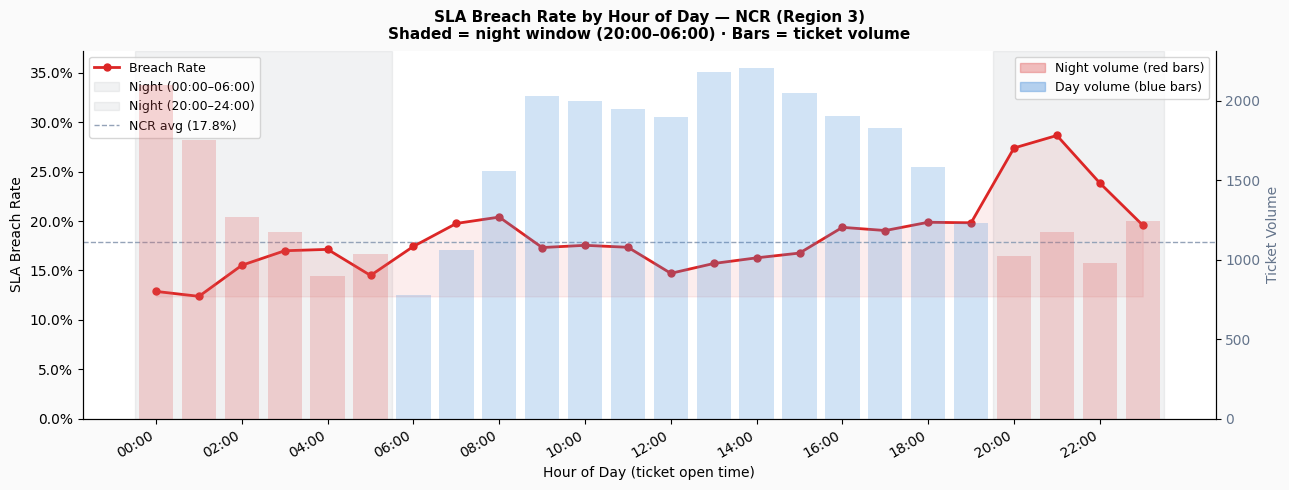

Night (20:00–06:00) breach rate: 18.0%
Day   (06:00–20:00) breach rate: 17.7%
Gap: 0.3% pp


In [3]:
# ── Figure 1: Hourly breach rate + volume dual-axis ───────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')
ax2 = ax1.twinx()

# Volume bars
bar_colors = ['#e05c5c' if h >= 20 or h < 6 else '#4a90d9' for h in hourly['Hour']]
ax2.bar(hourly['Hour'], hourly['Tickets'], color=bar_colors, alpha=0.25, width=0.8, zorder=1)
ax2.set_ylabel('Ticket Volume', color='#64748b', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#64748b')

# Breach rate line
ax1.plot(hourly['Hour'], hourly['Breach_Rate'], 'o-',
         color='#dc2626', lw=2, ms=5, zorder=3, label='Breach Rate')
ax1.fill_between(hourly['Hour'], hourly['Breach_Rate'],
                  hourly['Breach_Rate'].min(), alpha=0.08, color='#dc2626')

# Night shading
ax1.axvspan(-0.5, 5.5,  alpha=0.06, color='#1e293b', label='Night (00:00–06:00)')
ax1.axvspan(19.5, 23.5, alpha=0.06, color='#1e293b', label='Night (20:00–24:00)')

# NCR average line
ncr_breach = 1 - df_zone['SLA_Compliant'].mean()
ax1.axhline(ncr_breach, color='#94a3b8', ls='--', lw=1, label=f'NCR avg ({ncr_breach:.1%})')

ax1.set_xlabel('Hour of Day (ticket open time)', fontsize=10)
ax1.set_ylabel('SLA Breach Rate', fontsize=10)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_xticks(range(0, 24, 2))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=30, ha='right')
ax1.set_ylim(0, hourly['Breach_Rate'].max() * 1.3)

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper left', fontsize=9)

import matplotlib.patches as mpatches
night_patch = mpatches.Patch(color='#e05c5c', alpha=0.4, label='Night volume (red bars)')
day_patch   = mpatches.Patch(color='#4a90d9', alpha=0.4, label='Day volume (blue bars)')
ax2.legend(handles=[night_patch, day_patch], loc='upper right', fontsize=9)

ax1.set_title('SLA Breach Rate by Hour of Day — NCR (Region 3)\n'
              'Shaded = night window (20:00–06:00) · Bars = ticket volume',
              fontsize=11, fontweight='bold', pad=8)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig01_hourly_breach_profile.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

night_breach = df_zone[df_zone['Is_Night']==1]['SLA_Compliant'].agg(lambda x: 1-x.mean())
day_breach   = df_zone[df_zone['Is_Night']==0]['SLA_Compliant'].agg(lambda x: 1-x.mean())
print(f"Night (20:00–06:00) breach rate: {night_breach:.1%}")
print(f"Day   (06:00–20:00) breach rate: {day_breach:.1%}")
print(f"Gap: {abs(night_breach - day_breach):.1%} pp")

## 3. Hourly Breach by Zone — Heatmap

Which zones drive the night-time breach concentration?

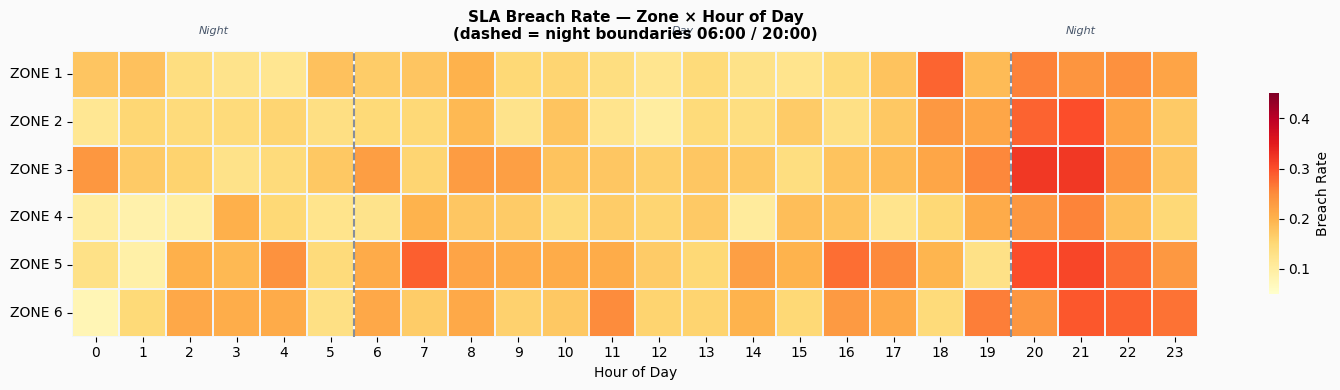

In [4]:
hourly_zone = (
    df_zone.groupby(['ZONE', 'Hour'])['SLA_Compliant']
    .agg(lambda x: 1 - x.mean())
    .reset_index(name='Breach_Rate')
)
pivot_hz = hourly_zone.pivot(index='ZONE', columns='Hour', values='Breach_Rate')
pivot_hz = pivot_hz.reindex(ZONE_ORDER)

fig, ax = plt.subplots(figsize=(15, 4))
fig.patch.set_facecolor('#fafafa')

sns.heatmap(
    pivot_hz, ax=ax,
    cmap='YlOrRd', vmin=0.05, vmax=0.45,
    linewidths=0.3, linecolor='#f1f5f9',
    cbar_kws={'label': 'Breach Rate', 'shrink': 0.7},
    annot=False,
)

# Mark night boundaries
ax.axvline(6,  color='#1e293b', lw=1.5, ls='--', alpha=0.5)
ax.axvline(20, color='#1e293b', lw=1.5, ls='--', alpha=0.5)
ax.text(3,  -0.35, 'Night', ha='center', fontsize=8, color='#475569', style='italic')
ax.text(13, -0.35, 'Day',   ha='center', fontsize=8, color='#475569', style='italic')
ax.text(21.5,-0.35,'Night', ha='center', fontsize=8, color='#475569', style='italic')

ax.set_title('SLA Breach Rate — Zone × Hour of Day\n'
             '(dashed = night boundaries 06:00 / 20:00)',
             fontsize=11, fontweight='bold', pad=8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig02_hourly_zone_heatmap.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

## 4. Night vs Day — Resolution Path Decomposition

Is the higher night breach rate driven by a different mix of resolution paths, or is the same path profile just performing worse at night?

In [5]:
path_labels = {
    'Auto_Self_Restored'     : 'Auto',
    'NOC_Remote_Restored'    : 'NOC Remote',
    'Field_Dispatch_Restored': 'Field Dispatch',
}

night_day = (
    df_zone.groupby(['Is_Night', 'Resolution_Path'])
    .agg(
        Tickets     = ('SLA_Compliant', 'count'),
        Breach_Rate = ('SLA_Compliant', lambda x: 1 - x.mean()),
        Avg_MTTR    = ('OUTAGEDURATION', 'mean'),
    )
    .reset_index()
)
night_day['Period']   = night_day['Is_Night'].map({0: 'Day (06:00–20:00)', 1: 'Night (20:00–06:00)'})
night_day['Path_Lbl'] = night_day['Resolution_Path'].map(path_labels)

# Mix share within each period
night_day['Mix_Share'] = night_day.groupby('Is_Night')['Tickets'].transform(lambda x: x / x.sum())

display(Markdown('### Table 2 — Resolution Path Mix and Breach Rate: Night vs Day'))
display(night_day[['Period','Path_Lbl','Tickets','Mix_Share','Breach_Rate','Avg_MTTR']]
    .rename(columns={'Path_Lbl':'Resolution Path','Mix_Share':'Share of Period'})
    .style
    .hide(axis='index')
    .format({
        'Tickets'          : '{:,}',
        'Share of Period'  : '{:.1%}',
        'Breach_Rate'      : '{:.1%}',
        'Avg_MTTR'         : '{:.1f}h',
    })
    .background_gradient(subset=['Breach_Rate'], cmap='YlOrRd', vmin=0.05, vmax=0.40)
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px')]},
        {'selector':'tr:nth-child(even)','props':[('background-color','#f7f9fc')]},
    ])
    .set_caption('Table 2 — Path mix and breach rates split by night vs day window')
)

### Table 2 — Resolution Path Mix and Breach Rate: Night vs Day

Period,Resolution Path,Tickets,Share of Period,Breach_Rate,Avg_MTTR
Day (06:00–20:00),Auto,"1,318",5.4%,10.1%,36.6h
Day (06:00–20:00),Field Dispatch,"15,535",64.0%,23.6%,79.8h
Day (06:00–20:00),NOC Remote,"7,404",30.5%,6.7%,26.7h
Night (20:00–06:00),Auto,"1,007",8.0%,10.0%,57.7h
Night (20:00–06:00),Field Dispatch,"7,287",57.6%,24.1%,53.2h
Night (20:00–06:00),NOC Remote,"4,356",34.4%,9.7%,47.7h


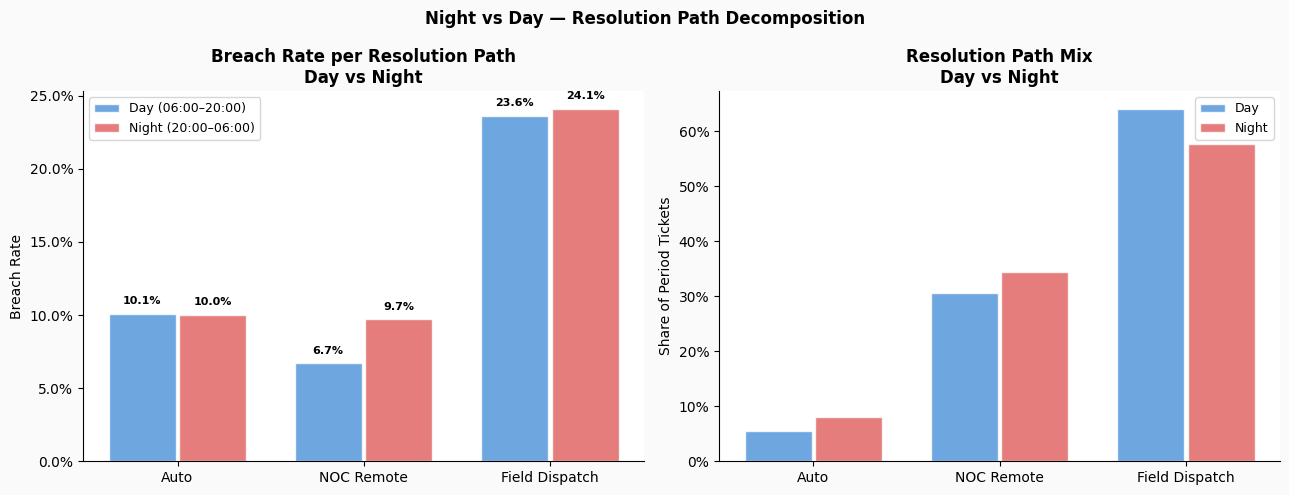

Key observation — Field Dispatch:
  Day breach rate  : 23.6%
  Night breach rate: 24.1%
  Gap: +0.5% pp — small; treat as provisional, not confirmed, without a
  significance test. Working hypothesis: night-opened FD tickets cannot begin
  on-site work until morning. Not yet tested directly against dispatch-delay data.


In [6]:
# ── Figure 3: Night vs Day breach rate per path ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')

paths = ['Auto_Self_Restored','NOC_Remote_Restored','Field_Dispatch_Restored']
path_colors = {'Auto_Self_Restored':'#2ca02c','NOC_Remote_Restored':'#5b9bd5',
               'Field_Dispatch_Restored':'#ed7d31'}

# Left: breach rate per path × period
ax = axes[0]
for j, (period_val, period_lbl, ls) in enumerate([
    (0, 'Day (06:00–20:00)', '-'),
    (1, 'Night (20:00–06:00)', '--'),
]):
    sub = night_day[night_day['Is_Night'] == period_val].set_index('Resolution_Path')
    x = np.arange(len(paths))
    bars = ax.bar(x + j*0.38 - 0.19, [sub.loc[p,'Breach_Rate'] if p in sub.index else 0 for p in paths],
                  0.36, label=period_lbl,
                  color=['#4a90d9' if j==0 else '#e05c5c']*3,
                  alpha=0.8, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.1%}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(np.arange(len(paths)))
ax.set_xticklabels([path_labels[p] for p in paths])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Breach Rate')
ax.set_title('Breach Rate per Resolution Path\nDay vs Night', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: mix shift
ax2 = axes[1]
for j, (period_val, period_lbl) in enumerate([(0,'Day'),(1,'Night')]):
    sub = night_day[night_day['Is_Night'] == period_val].set_index('Resolution_Path')
    x = np.arange(len(paths))
    ax2.bar(x + j*0.38 - 0.19,
            [sub.loc[p,'Mix_Share'] if p in sub.index else 0 for p in paths],
            0.36, label=period_lbl,
            color=['#4a90d9' if j==0 else '#e05c5c']*3, alpha=0.8, edgecolor='white')

ax2.set_xticks(np.arange(len(paths)))
ax2.set_xticklabels([path_labels[p] for p in paths])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Share of Period Tickets')
ax2.set_title('Resolution Path Mix\nDay vs Night', fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Night vs Day — Resolution Path Decomposition', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig03_night_day_path_decomp.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

# Key interpretation
fd_day   = night_day[(night_day['Is_Night']==0) & (night_day['Resolution_Path']=='Field_Dispatch_Restored')]
fd_night = night_day[(night_day['Is_Night']==1) & (night_day['Resolution_Path']=='Field_Dispatch_Restored')]
print('Key observation — Field Dispatch:')
if not fd_day.empty and not fd_night.empty:
    fd_gap = fd_night['Breach_Rate'].values[0] - fd_day['Breach_Rate'].values[0]
    print(f"  Day breach rate  : {fd_day['Breach_Rate'].values[0]:.1%}")
    print(f"  Night breach rate: {fd_night['Breach_Rate'].values[0]:.1%}")
    print(f"  Gap: {fd_gap:+.1%} pp — small; treat as provisional, not confirmed, without a")
    print(f"  significance test. Working hypothesis: night-opened FD tickets cannot begin")
    print(f"  on-site work until morning. Not yet tested directly against dispatch-delay data.")

## 5. Day-of-Week SLA Profile

In [7]:
dow = (
    df_zone.groupby('DayOfWeek')
    .agg(
        Tickets     = ('SLA_Compliant', 'count'),
        SLA_Rate    = ('SLA_Compliant', 'mean'),
        Breach_Rate = ('SLA_Compliant', lambda x: 1 - x.mean()),
        Avg_MTTR    = ('OUTAGEDURATION', 'mean'),
        FD_Rate     = ('Is_FD', 'mean'),
    )
    .reindex(DOW_ORDER)
    .reset_index()
)
dow.to_csv('output/p7_dow_sla_profile.csv', index=False)

display(Markdown('### Table 3 — Day-of-Week SLA Profile — NCR Wide'))
display(dow.style
    .hide(axis='index')
    .format({
        'Tickets'    : '{:,}',
        'SLA_Rate'   : '{:.1%}',
        'Breach_Rate': '{:.1%}',
        'Avg_MTTR'   : '{:.1f}h',
        'FD_Rate'    : '{:.1%}',
    })
    .background_gradient(subset=['Breach_Rate'], cmap='YlOrRd', vmin=0.10, vmax=0.30)
    .set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),
                                   ('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td','props':[('padding','6px 10px'),('font-size','11px'),
                                   ('text-align','center')]},
    ])
    .set_caption('Table 3 — SLA breach rate by day of week · saved to p7_dow_sla_profile.csv')
)
print(f"\nSaved: output/p7_dow_sla_profile.csv")

### Table 3 — Day-of-Week SLA Profile — NCR Wide

DayOfWeek,Tickets,SLA_Rate,Breach_Rate,Avg_MTTR,FD_Rate
Monday,"5,235",81.3%,18.7%,48.8h,59.7%
Tuesday,"5,367",82.6%,17.4%,49.8h,61.8%
Wednesday,"5,789",84.4%,15.6%,84.2h,53.9%
Thursday,"5,416",82.5%,17.5%,60.2h,62.5%
Friday,"5,096",81.1%,18.9%,53.1h,64.4%
Saturday,"5,205",81.1%,18.9%,51.2h,66.0%
Sunday,"4,799",81.7%,18.3%,55.3h,65.8%



Saved: output/p7_dow_sla_profile.csv


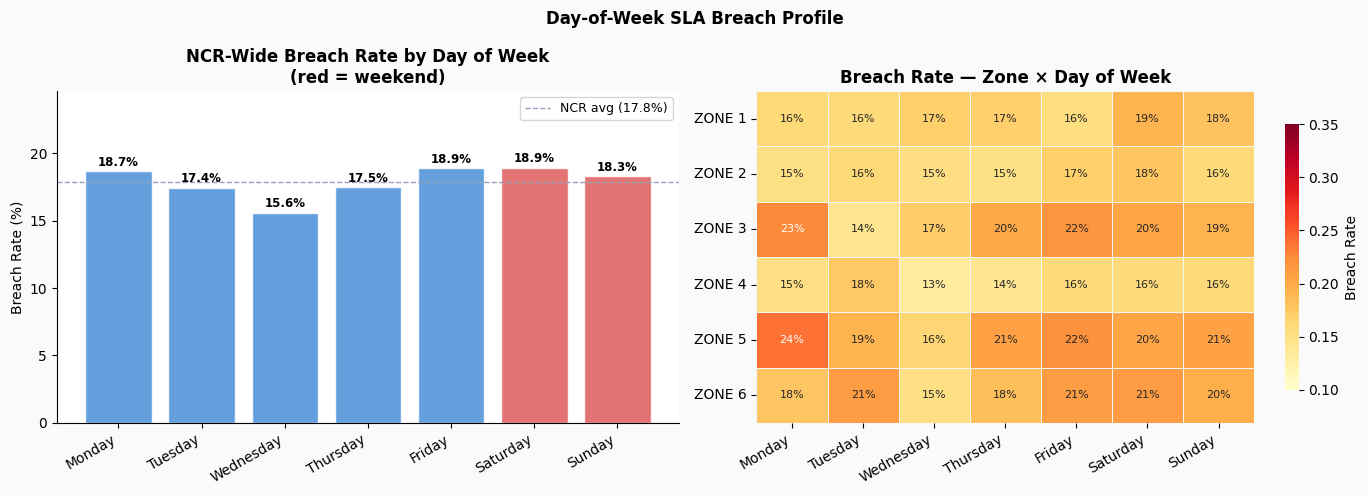

Highest breach day: Saturday (18.9%)
Lowest breach day : Wednesday (15.6%)
Weekend avg breach: 18.6%  |  Weekday avg breach: 17.6%  |  Gap: 1.1% pp


In [8]:
# ── Figure 4: DoW breach rate + zone breakdown ────────────────────────────────
dow_zone = (
    df_zone.groupby(['DayOfWeek', 'ZONE'])['SLA_Compliant']
    .agg(lambda x: 1 - x.mean())
    .reset_index(name='Breach_Rate')
)
pivot_dz = dow_zone.pivot(index='DayOfWeek', columns='ZONE', values='Breach_Rate').reindex(DOW_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#fafafa')

# Left: NCR-wide DoW breach
ax = axes[0]
bar_colors = ['#e05c5c' if d in ['Saturday','Sunday'] else '#4a90d9' for d in dow['DayOfWeek']]
bars = ax.bar(dow['DayOfWeek'], dow['Breach_Rate'] * 100, color=bar_colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, dow['Breach_Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1%}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.axhline(ncr_breach * 100, color='#94a3b8', ls='--', lw=1, label=f'NCR avg ({ncr_breach:.1%})')
ax.set_ylabel('Breach Rate (%)')
ax.set_ylim(0, dow['Breach_Rate'].max() * 130)
ax.set_title('NCR-Wide Breach Rate by Day of Week\n(red = weekend)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Right: zone heatmap by DoW
ax2 = axes[1]
sns.heatmap(
    pivot_dz.T.reindex(ZONE_ORDER),
    ax=ax2, cmap='YlOrRd', vmin=0.10, vmax=0.35,
    linewidths=0.5, linecolor='#f1f5f9',
    annot=True, fmt='.0%', annot_kws={'size':8},
    cbar_kws={'label':'Breach Rate','shrink':0.8},
)
ax2.set_title('Breach Rate — Zone × Day of Week', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('')
plt.yticks(rotation=0)
plt.xticks(rotation=30, ha='right')

plt.suptitle('Day-of-Week SLA Breach Profile', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig04_dow_breach_profile.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

worst_day = dow.loc[dow['Breach_Rate'].idxmax(), 'DayOfWeek']
best_day  = dow.loc[dow['Breach_Rate'].idxmin(), 'DayOfWeek']
print(f"Highest breach day: {worst_day} ({dow.loc[dow['Breach_Rate'].idxmax(),'Breach_Rate']:.1%})")
print(f"Lowest breach day : {best_day} ({dow.loc[dow['Breach_Rate'].idxmin(),'Breach_Rate']:.1%})")
weekend_br = df_zone[df_zone['Is_Weekend']==1]['SLA_Compliant'].agg(lambda x: 1-x.mean())
weekday_br = df_zone[df_zone['Is_Weekend']==0]['SLA_Compliant'].agg(lambda x: 1-x.mean())
print(f"Weekend avg breach: {weekend_br:.1%}  |  Weekday avg breach: {weekday_br:.1%}  |  Gap: {abs(weekend_br-weekday_br):.1%} pp")

## 6. Key Findings

In [9]:
peak_hour = hourly.loc[hourly['Breach_Rate'].idxmax(), 'Hour']
peak_br   = hourly['Breach_Rate'].max()

print('='*65)
print('  NB22 — KEY FINDINGS')
print('='*65)
print(f"  Peak breach hour      : {peak_hour:02d}:00 ({peak_br:.1%})")
print(f"  Night breach rate     : {night_breach:.1%}  (vs {day_breach:.1%} daytime)")
print(f"  Night/day gap         : {abs(night_breach-day_breach):.1%} pp")
print(f"  Worst day of week     : {worst_day}")
print(f"  Weekend vs weekday gap: {abs(weekend_br-weekday_br):.1%} pp")
print()
if not fd_day.empty and not fd_night.empty:
    print(f"  FD night breach rate  : {fd_night['Breach_Rate'].values[0]:.1%}")
    print(f"  FD day breach rate    : {fd_day['Breach_Rate'].values[0]:.1%}")
    print(f"  Interpretation: gap is small (0.5pp) — provisional, pending a significance")
    print(f"  test. The Saturday 20:00–24:00 window (see NB23) is a stronger, already-")
    print(f"  confirmed signal and should be prioritized over a blanket night policy.")
print('='*65)
print("  → Proceed to NB23: Seasonal Decomposition & Schedule Alignment")

  NB22 — KEY FINDINGS
  Peak breach hour      : 21:00 (28.7%)
  Night breach rate     : 18.0%  (vs 17.7% daytime)
  Night/day gap         : 0.3% pp
  Worst day of week     : Saturday
  Weekend vs weekday gap: 1.1% pp

  FD night breach rate  : 24.1%
  FD day breach rate    : 23.6%
  Interpretation: gap is small (0.5pp) — provisional, pending a significance
  test. The Saturday 20:00–24:00 window (see NB23) is a stronger, already-
  confirmed signal and should be prioritized over a blanket night policy.
  → Proceed to NB23: Seasonal Decomposition & Schedule Alignment
